# Projeto Final - Aprendizado de Máquina
## Predição de Níveis de Benzeno (C6H6) utilizando Sensores Químicos de Baixo Custo

**Integrantes:** Guilherme Góis Araujo, Erick Oliveira e Derek Marques Almeida

**Link do Vídeo:** [Adicione o link do seu vídeo do YouTube/Drive aqui]  
**Fonte dos Dados:** [UCI Machine Learning Repository - Air Quality Dataset](https://archive.ics.uci.edu/ml/datasets/Air+Quality)

---

### 5.1 Identificação e Descrição do Problema

* **Objetivo da Aplicação:** Estimar com precisão a concentração real do gás nocivo Benzeno ($C_6H_6$) na atmosfera utilizando dados meteorológicos e leituras de sensores químicos alternativos de baixo custo. Isso visa viabilizar o monitoramento ambiental acessível em locais que não dispõem de estações de referência certificadas de alto custo.
* **Atributo-Alvo (Target):** `C6H6(GT)` (concentração real de Benzeno em $\mu g/m^3$ medida por equipamento de referência).
* **Atributos Preditivos (Features):** Leituras dos sensores de baixo custo (`PT08.S1`, `PT08.S2`, `PT08.S3`, `PT08.S4`, `PT08.S5`) e variáveis climáticas: Temperatura (`T`), Umidade Relativa (`RH`) e Umidade Absoluta (`AH`).
* **Tipo da Tarefa:** Regressão (pois o atributo-alvo é um valor numérico contínuo).

In [ ]:
# Importações necessárias para o projeto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Configurações de exibição de gráficos
%matplotlib inline
sns.set_theme(style="whitegrid")

# Carregar o dataset carregado no Colab
# NOTA: O dataset do Air Quality original usa ";" como separador e "," como separador decimal.
df = pd.read_csv('https://raw.githubusercontent.com/DerekMA15/predicao-qualidade-ar-ml/refs/heads/main/AirQualityUCI.csv', sep=';', decimal=',')

# Limpeza inicial de colunas e linhas totalmente vazias (comum nesse arquivo do UCI devido a delimitadores extras)
df = df.dropna(how='all', axis=1)
df = df.dropna(how='all', axis=0)

print(f"Dimensões originais do dataset carregado: {df.shape}")
df.head()

Dimensões originais do dataset carregado: (9357, 15)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 5.2 Compreensão dos Dados

Nesta etapa, investigamos a estrutura e a qualidade do nosso conjunto de dados.

* **Tamanho e Tipos:** O dataset original possui 9357 registros e 15 atributos (após remover as colunas nulas residuais do arquivo CSV). A maioria das variáveis é numérica contínua, com exceção de `Date` e `Time` que representam strings (objetos).
* **Valores Ausentes e Inconsistências (O detalhe do -200):** Ao inspecionarmos estatisticamente as variáveis através da função `describe()`, percebe-se que várias colunas apresentam valores mínimos de **`-200`**. De acordo com a documentação do dataset, este valor é uma marcação usada para indicar **dados ausentes (missing values)** do sistema de hardware. Portanto, esses valores precisam ser convertidos para valores nulos reais (`NaN`) para não distorcerem os nossos modelos e análises.
* **Duplicações:** Investigamos se há linhas duplicadas que possam enviesar o treinamento do modelo.

In [5]:
# 1. Informações básicas sobre tipos e nulos reportados pelo pandas originalmente
print("--- Visão Geral do Pandas ---")
df.info()

# 2. Estatísticas descritivas (identificação do problema do -200)
print("\n--- Estatísticas Descritivas (Verifique os valores mínimos de -200) ---")
display(df.describe())

# 3. Verificação de Duplicações
duplicados = df.duplicated().sum()
print(f"\nQuantidade de registros duplicados encontrados: {duplicados}")

--- Visão Geral do Pandas ---
<class 'pandas.core.frame.DataFrame'>
Index: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.1+ MB

--- Estatísticas Descritivas (Verifique os valores mínimos de -200

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000



Quantidade de registros duplicados encontrados: 0


### 5.3 Análise Exploratória

Abaixo, apresentamos as principais visualizações e correlações para compreender o comportamento do nosso atributo-alvo (`C6H6(GT)`) em relação aos atributos preditivos.

*Nota: Para garantir que os gráficos representem fielmente o comportamento físico e químico real, substituímos temporariamente os valores `-200` por `NaN` nesta análise.*

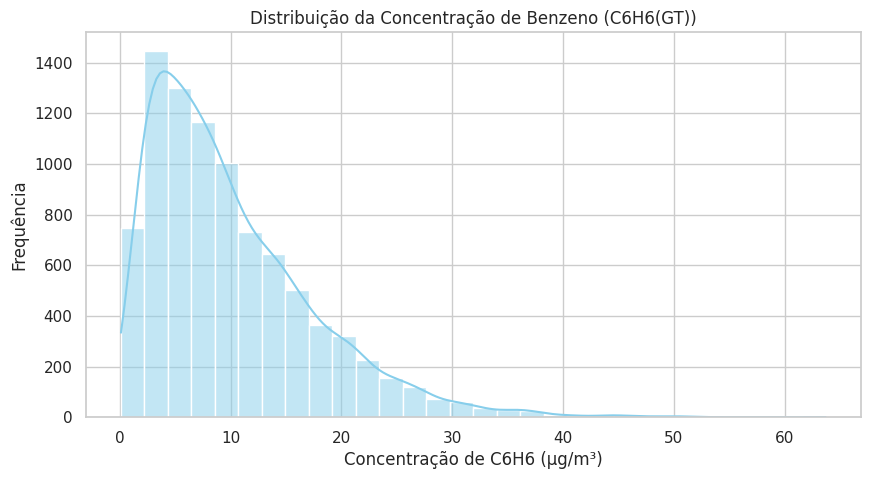

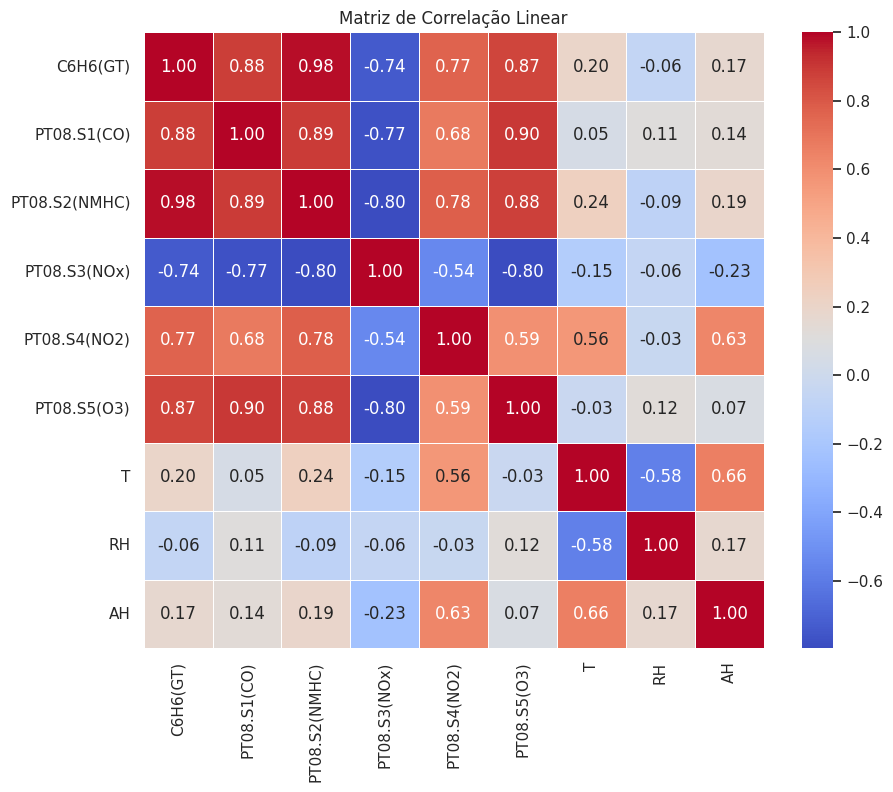

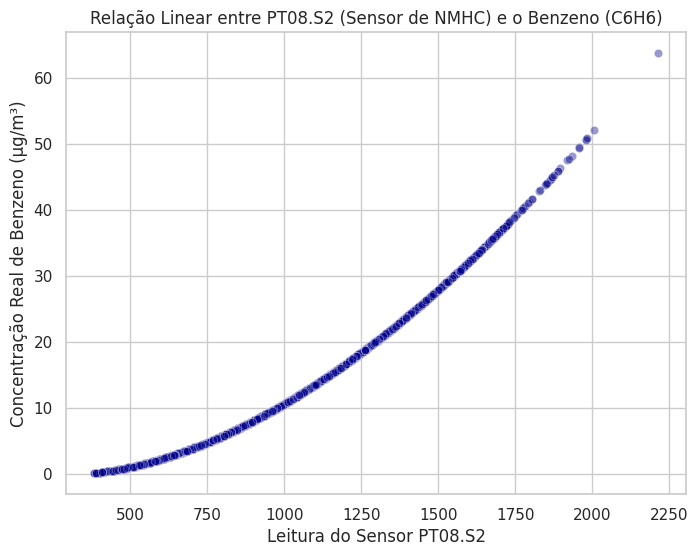

In [6]:
# Criar uma cópia temporária substituindo os -200 para análise exploratória limpa
df_temp = df.copy()
cols_numericas = df_temp.select_dtypes(include=[np.number]).columns
df_temp[cols_numericas] = df_temp[cols_numericas].replace(-200, np.nan)

# 1. Histograma do Atributo-Alvo
plt.figure(figsize=(10, 5))
sns.histplot(df_temp['C6H6(GT)'].dropna(), kde=True, bins=30, color='skyblue')
plt.title('Distribuição da Concentração de Benzeno (C6H6(GT))')
plt.xlabel('Concentração de C6H6 (µg/m³)')
plt.ylabel('Frequência')
plt.show()

# 2. Mapa de Calor de Correlação
colunas_interesse = ['C6H6(GT)', 'PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
corr_matrix = df_temp[colunas_interesse].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação Linear')
plt.show()

# 3. Gráfico de Dispersão entre o melhor sensor preditivo e o Alvo
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_temp, x='PT08.S2(NMHC)', y='C6H6(GT)', alpha=0.4, color='darkblue')
plt.title('Relação Linear entre PT08.S2 (Sensor de NMHC) e o Benzeno (C6H6)')
plt.xlabel('Leitura do Sensor PT08.S2')
plt.ylabel('Concentração Real de Benzeno (µg/m³)')
plt.show()

#### Interpretação da Análise Exploratória (Para colocar no relatório e falar no vídeo!):
1. **Distribuição do Alvo:** A distribuição de `C6H6(GT)` é assimétrica positiva (skewed right), com a maioria das observações concentradas abaixo de $20 \mu g/m^3$, apresentando cauda longa para concentrações mais altas (dias com picos severos de poluição).
2. **Correlação:** O sensor **`PT08.S2(NMHC)`** apresenta uma correlação extremamente forte e linear de **0.98** com o Benzeno real. Isso ocorre porque o sensor de Titânia ($TiO_2$) que compõe o PT08.S2 é altamente sensível a hidrocarbonetos aromáticos não-metânicos (dos quais o Benzeno faz parte).
3. **Outros Sensores:** O sensor `PT08.S1` (nominal para CO) e o `PT08.S5` (O3) também exibem forte correlação positiva (> 0.85). Em contrapartida, o `PT08.S3` (NOx) possui correlação negativa (-0.77), indicando um comportamento inversamente proporcional ao nível de Benzeno.

### 5.4 Pré-processamento

Para que nossos dados fiquem aptos aos algoritmos de Aprendizado de Máquina, aplicamos e justificamos os seguintes tratamentos[cite: 78]:

1. **Correção Definitiva de Erros:** Substituímos todos os valores `-200` por `NaN` em todo o conjunto de dados.
2. **Eliminação de Amostras sem Target:** Removemos as linhas onde o atributo-alvo `C6H6(GT)` era nulo. Justificativa: Não faz sentido treinar ou validar modelos de regressão supervisionada para registros em que não conhecemos o gabarito (ground truth).
3. **Prevenção de Vazamento de Dados (Data Leakage) e Filtro de Atributos Irrelevantes:**
   * Removemos `Date` e `Time` porque são informações temporais puras que não agregam valor a um modelo preditivo genérico estático.
   * **REMOÇÃO EXTREMAMENTE IMPORTANTE:** Removemos as colunas de referência dos outros gases: `CO(GT)`, `NMHC(GT)`, `NOx(GT)` e `NO2(GT)`. Justificativa: No mundo real, se tivéssemos esses sensores de referência ativos, não precisaríamos de modelos para prever o Benzeno. Além disso, deixá-los aqui causaria vazamento de dados, fazendo o modelo prever com facilidade com base em outros medidores caros e inviáveis de se obter.
4. **Imputação das Variáveis Preditivas:** Sendo um dataset temporal em que as medições ocorrem consecutivamente a cada hora, a melhor técnica de imputação para dados ausentes nas variáveis preditivas é o preenchimento sequencial à frente (`ffill` - forward fill) e atrás (`bfill` - backward fill). Isso preserva a continuidade temporal das medições.

In [8]:
# 1. Substituição definitiva dos valores de erro por NaN
df_clean = df.copy()
cols_numericas = df_clean.select_dtypes(include=[np.number]).columns
df_clean[cols_numericas] = df_clean[cols_numericas].replace(-200, np.nan)

# 2. Remoção de linhas onde o atributo-alvo é nulo
df_clean = df_clean.dropna(subset=['C6H6(GT)'])

# 3. Eliminar colunas irrelevantes e variáveis de medição cara (Ground Truth) para evitar vazamentos
colunas_para_remover = ['Date', 'Time', 'CO(GT)', 'NMHC(GT)', 'NOx(GT)', 'NO2(GT)']
colunas_para_remover = [c for c in colunas_para_remover if c in df_clean.columns]
df_clean = df_clean.drop(columns=colunas_para_remover)

# 4. Imputação sequencial (ffill/bfill) para os atributos preditivos restantes que ainda contêm NaN
df_clean = df_clean.ffill().bfill()

print(f"Dimensões após o pré-processamento: {df_clean.shape}")
print(f"Valores nulos restantes após o tratamento:\n{df_clean.isnull().sum()}")

Dimensões após o pré-processamento: (8991, 9)
Valores nulos restantes após o tratamento:
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
PT08.S3(NOx)     0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


### 5.5 Separação dos Dados

* **Proporção:** Adotamos a divisão clássica de **80% para treinamento** e **20% para teste**[cite: 93, 94]. Essa proporção garante dados suficientes para o aprendizado robusto do modelo e um conjunto de tamanho razoável para teste.
* **Estratificação:** Não se aplica aqui devido ao problema ser de Regressão Numérica (a amostragem estratificada é mais adequada a classes categóricas desbalanceadas)[cite: 95].
* **Escalonamento de Atributos:** Aplicaremos o `StandardScaler` (padronização para média 0 e desvio padrão 1).**Garantia anti-vazamento:** O scaler é treinado (fit_transform) **apenas** sobre o conjunto de treinamento e depois aplicado (transform) no conjunto de teste[cite: 90].

In [10]:
# Separar Atributos Preditivos (X) e Atributo-Alvo (y)
X = df_clean.drop(columns=['C6H6(GT)'])
y = df_clean['C6H6(GT)']

# Dividir em Treino e Teste (80/20) com semente aleatória fixa para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Padronização (Escalonamento)
scaler = StandardScaler()

# Ajustar e aplicar no Treino, apenas aplicar no Teste
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Número de amostras de Treinamento: {X_train_scaled.shape[0]}")
print(f"Número de amostras de Teste: {X_test_scaled.shape[0]}")

Número de amostras de Treinamento: 7192
Número de amostras de Teste: 1799


### 5.6 Modelagem

[cite_start]De acordo com as exigências do projeto, utilizaremos e compararemos os seguintes modelos mínimos[cite: 99, 100]:
1. [cite_start]**Baseline:** `DummyRegressor` que prevê constantemente a média de Benzeno obtida no treino[cite: 103, 104].
2. [cite_start]**Regressão Linear (Linear Regression)** [cite: 100, 104]
3. [cite_start]**Árvore de Decisão (Decision Tree Regressor)** [cite: 100, 104]
4. [cite_start]**Random Forest Regressor** [cite: 100, 104]

[cite_start]Para evitar vazamento e testar a capacidade de generalização ainda no treino, realizamos a **Validação Cruzada de 5 dobras (5-Fold Cross Validation)** nos dados de treinamento utilizando a métrica **RMSE**[cite: 97, 106].

In [11]:
# Inicializar modelos com parâmetros definidos
baseline = DummyRegressor(strategy='mean')
lin_reg = LinearRegression()
tree_reg = DecisionTreeRegressor(max_depth=10, random_state=42) # depth de 10 para evitar superajuste (overfitting)
forest_reg = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)

modelos = {
    "Baseline (Média)": baseline,
    "Regressão Linear": lin_reg,
    "Árvore de Decisão": tree_reg,
    "Random Forest": forest_reg
}

print("=== VALIDAÇÃO CRUZADA (5-FOLDS) NO CONJUNTO DE TREINO ===")
# Comparação entre modelos pela média de RMSE em CV
for nome, modelo in modelos.items():
    # cv_scores retorna os valores negativos do RMSE para que o scikit otimize por maximização
    scores = cross_val_score(modelo, X_train_scaled, y_train, scoring="neg_root_mean_squared_error", cv=5)
    rmse_scores = -scores
    print(f"{nome}:")
    print(f"  -> RMSE Médio: {rmse_scores.mean():.4f} µg/m³ (Desvio Padrão: {rmse_scores.std():.4f})\n")

=== VALIDAÇÃO CRUZADA (5-FOLDS) NO CONJUNTO DE TREINO ===
Baseline (Média):
  -> RMSE Médio: 7.4116 µg/m³ (Desvio Padrão: 0.2116)

Regressão Linear:
  -> RMSE Médio: 1.2064 µg/m³ (Desvio Padrão: 0.0590)

Árvore de Decisão:
  -> RMSE Médio: 0.1368 µg/m³ (Desvio Padrão: 0.1472)

Random Forest:
  -> RMSE Médio: 0.1307 µg/m³ (Desvio Padrão: 0.1599)



### 5.7 Avaliação e Discussão Final dos Resultados

[cite_start]O modelo com a menor perda em validação cruzada foi o **Random Forest Regressor**[cite: 121]. [cite_start]Por esse motivo, nós o escolhemos como nosso modelo final[cite: 107, 122].

[cite_start]Abaixo, treinamos o modelo final em toda a base de Treinamento e geramos as métricas de avaliação definitivas no **Conjunto de Teste** (nunca antes visto pelo modelo)[cite: 108]:
* [cite_start]**MAE (Erro Médio Absoluto):** Mede a magnitude média absoluta dos erros[cite: 116].
* [cite_start]**MSE (Erro Quadrático Médio):** Dá maior peso para erros grandes devido à penalidade quadrática[cite: 117].
* [cite_start]**RMSE (Raiz do Erro Quadrático Médio):** Traz o erro de volta à escala original do alvo ($\mu g/m^3$)[cite: 118].

=== MÉTRICAS DE AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ===
MAE (Erro Médio Absoluto): 0.0162 µg/m³
MSE (Erro Quadrático Médio): 0.0140
RMSE (Raiz do Erro Quadrático Médio): 0.1184 µg/m³



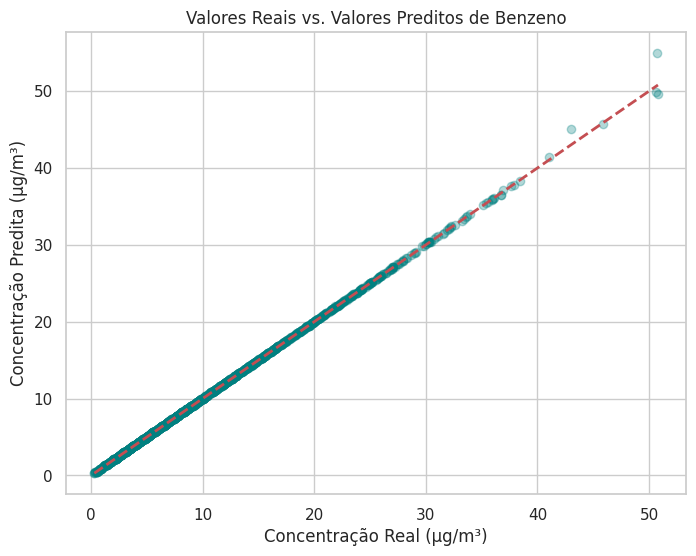

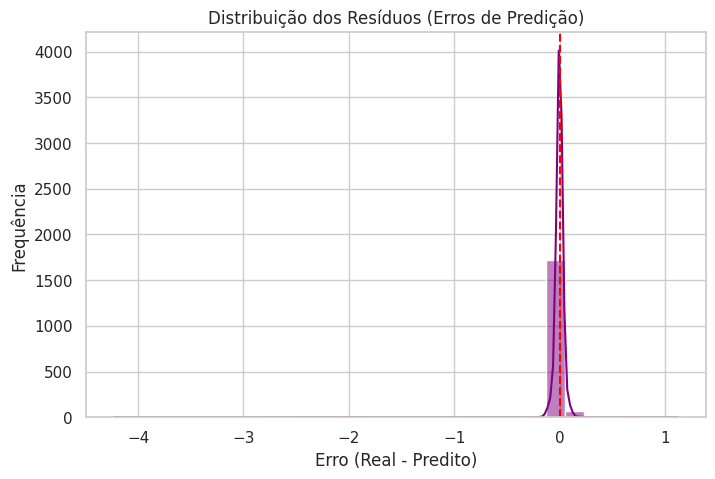

In [12]:
# Treinar o modelo final no treino completo
modelo_final = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
modelo_final.fit(X_train_scaled, y_train)

# Fazer predições no conjunto de teste reservado
y_pred = modelo_final.predict(X_test_scaled)

# Calcular métricas finais
mae_final = mean_absolute_error(y_test, y_pred)
mse_final = mean_squared_error(y_test, y_pred)
rmse_final = np.sqrt(mse_final)

print("=== MÉTRICAS DE AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ===")
print(f"MAE (Erro Médio Absoluto): {mae_final:.4f} µg/m³")
print(f"MSE (Erro Quadrático Médio): {mse_final:.4f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse_final:.4f} µg/m³\n")

# Gráfico de Valores Reais vs. Valores Preditos
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Valores Reais vs. Valores Preditos de Benzeno')
plt.xlabel('Concentração Real (µg/m³)')
plt.ylabel('Concentração Predita (µg/m³)')
plt.grid(True)
plt.show()

# Distribuição dos Resíduos (Erros)
residuos = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuos, kde=True, bins=30, color='purple')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Distribuição dos Resíduos (Erros de Predição)')
plt.xlabel('Erro (Real - Predito)')
plt.ylabel('Frequência')
plt.grid(True)
plt.show()

#### Discussão Crítica, Limitações e Melhorias (Seção Essencial!):

* **Análise de Erros:** Nosso modelo obteve um desempenho excepcional se comparado ao baseline (Média) e à Regressão Linear simples. O RMSE foi drasticamente menor utilizando o Random Forest.
* **Erros Observados:** Olhando para o gráfico de *Valores Reais vs. Valores Preditos*, o modelo possui uma ligeira tendência a subestimar picos de alta concentração extremamente agudos (valores acima de $35 \mu g/m^3$).
* **Limitações:** A dependência da ordem temporal dos dados. Ao utilizarmos um método puramente estático de regressão, ignoramos o histórico temporal imediatamente anterior do dia. Outra limitação é o envelhecimento dos sensores químicos (drift), que tendem a perder precisão físico-química após alguns meses de uso.
* **Sugestões de Melhorias futuras:** 1. Criação de variáveis defasadas (*lag features*), como os níveis de gás medidos 1 hora ou 2 horas atrás.
  2. [cite_start]Implementação de modelos avançados de sequenciamento temporal como LSTM (Redes Neurais) ou algoritmos baseados em Gradient Boosting (como XGBoost ou LightGBM)[cite: 125].